# Notebook 03: Foundation Model Training with **Ray Train**

| | Original | Ray |
|---|----------|-------------|
| Launch | `torchrun` per node, manual coordination | one `TorchTrainer.fit()`, multi-node |
| Distribution | NeMo + FSDP2 | Ray Train + `prepare_model` (DDP); FSDP available |
| Data | read `train_corpus.txt` into a Dataset | **Ray Data** Parquet shards via `get_dataset_shard` |
| Fault tolerance | crash = full restart | automatic worker restart + checkpoint resume |
| Checkpoint | NeMo consolidated safetensors | `ray.train.report(checkpoint=...)` → HF `save_pretrained` |

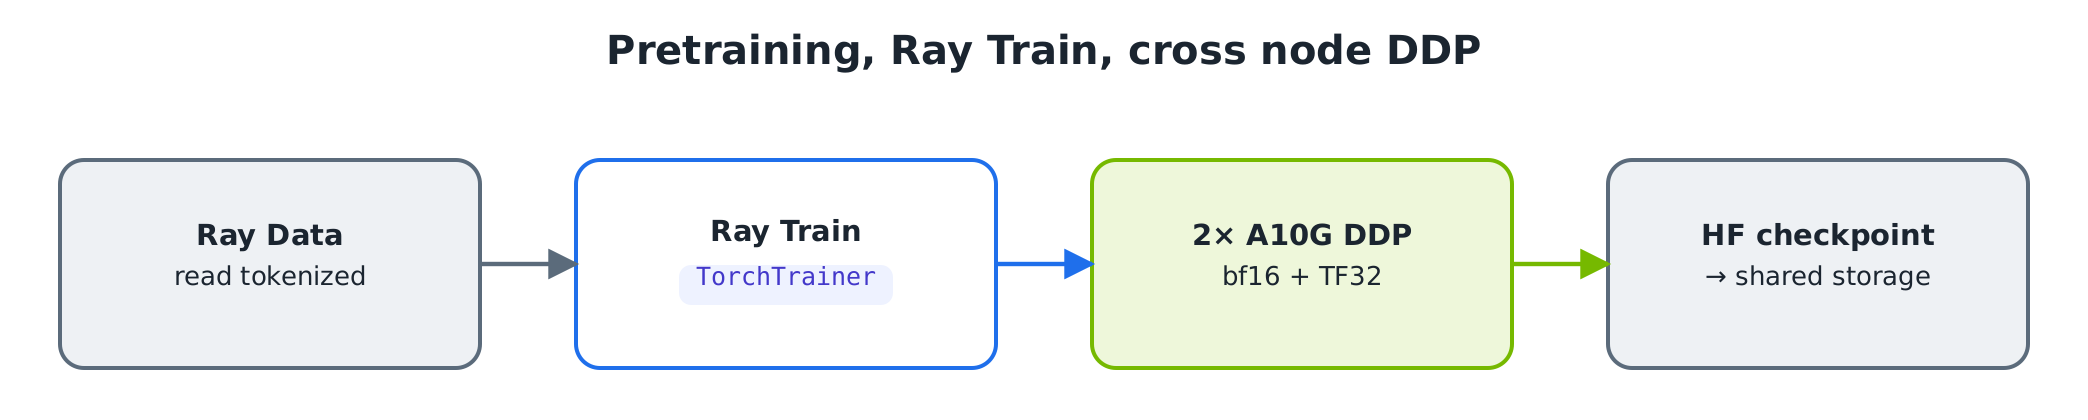

## `Step 0`: Setup

In [1]:
import json
from pathlib import Path

import ray
from src import ray_common as C

if not ray.is_initialized():
    # TRAIN_JOB_ENV = src package (py_modules) + GPU pip deps. Ray Train worker
    # actors inherit this job runtime_env, so torch/transformers are installed on
    # the workers; the head already has torch for building the TorchTrainer.
    ray.init(address="auto", runtime_env=C.TRAIN_JOB_ENV)
print(f"GPUs in cluster: {ray.cluster_resources().get('GPU', 0):.0f}")
print(f"Tokenized corpus (from NB02): {C.TOKENIZED_DIR}")

2026-06-10 18:49:32,782	INFO worker.py:1814 -- Connecting to existing Ray cluster at address: 10.0.128.242:6379...
2026-06-10 18:49:32,827	INFO worker.py:2003 -- Connected to Ray cluster. View the dashboard at https://session-qpwcx5l3g8cwbw1p61s98gvrp4.i.anyscaleuserdata.com 
2026-06-10 18:49:32,838	INFO packaging.py:691 -- Creating a file package for local module '/home/ray/default_cld_g54aiirwj1s8t9ktgzikqur41k/transaction-foundation-model-with-ray/src'.
2026-06-10 18:49:32,844	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_cbe59e9b9585113b.zip' (0.09MiB) to Ray cluster...
2026-06-10 18:49:32,845	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_cbe59e9b9585113b.zip'.
2026-06-10 18:49:32,849	INFO packaging.py:463 -- Pushing file package 'gcs://_ray_pkg_40652bbcadc0e80c63b8de675bc1e53527875999.zip' (2.15MiB) to Ray cluster...
2026-06-10 18:49:32,856	INFO packaging.py:476 -- Successfully pushed file package 'gcs://_ray_pkg_40652bbcadc0e80c63b8de67

GPUs in cluster: 2
Tokenized corpus (from NB02): /mnt/cluster_storage/tfm_ray/tokenized


/home/ray/anaconda3/lib/python3.12/site-packages/ray/_private/worker.py:2051: FutureWarning: Tip: In future versions of Ray, Ray will no longer override accelerator visible devices env var if num_gpus=0 or num_gpus=None (default). To enable this behavior and turn off this error message, set RAY_ACCEL_ENV_VAR_OVERRIDE_ON_ZERO=0
  warnings.warn(


## `Step 1`: Model configuration (~29M-param Llama decoder)

Identical architecture to the original blueprint, a small Llama config with RoPE, GQA (8 query / 2 KV heads), SwiGLU and RMSNorm. The random-init baseline
loss is `ln(vocab) = ln(6251) ≈ 8.74`; it should fall quickly as the model learns transaction patterns.

In [2]:
for k, v in C.MODEL_CONFIG.items():
    print(f"  {k}: {v}")
import math
print(f"\nRandom-baseline CE loss = ln({C.MODEL_CONFIG['vocab_size']}) = "
      f"{math.log(C.MODEL_CONFIG['vocab_size']):.2f}")

  vocab_size: 6251
  hidden_size: 512
  num_hidden_layers: 8
  num_attention_heads: 8
  num_key_value_heads: 2
  intermediate_size: 1408
  max_position_embeddings: 8192
  rope_theta: 500000.0
  hidden_act: silu
  rms_norm_eps: 1e-05
  attention_dropout: 0.0
  tie_word_embeddings: False
  bos_token_id: 1
  eos_token_id: 2
  pad_token_id: 0

Random-baseline CE loss = ln(6251) = 8.74


## `Step 2`: Launch distributed training

`train_loop_per_worker` runs on each A10G worker: build the HF model, wrap it
with `ray.train.torch.prepare_model` (DDP), pull this worker's **Ray Data shard**,
and run causal-LM next-token prediction (`labels = input_ids`, pad → `-100`).
Rank 0 saves the HF checkpoint (`config.json` + `safetensors`) to **shared
storage** and reports it as a Ray Train checkpoint.

`ScalingConfig(num_workers=2, use_gpu=True)` → data-parallel across two A10G
GPUs. On this cluster each `1xA10G` is a **single-GPU node**, so the two DDP
ranks live on **different nodes** and gradient all-reduce runs **cross-node over
NCCL** — Ray Train wires up the process group and `NCCL_SOCKET_IFNAME` for us, so
the same code scales from 2 single-GPU nodes to an 8-GPU node with no change
(scale by bumping `num_workers`). Best-practice touches: a streaming
shuffle buffer (`iter_torch_batches(local_shuffle_buffer_size=...)`) for SGD
randomness, and `RunConfig(failure_config=FailureConfig(max_failures=2))` so a
crashed/preempted worker is restarted and the run resumes from the last
checkpoint instead of starting over.

**A10G tuning.** A10G is an Ampere (SM 8.6) card with bf16/TF32 tensor cores, so
each worker sets `torch.set_float32_matmul_precision("high")` (TF32 matmuls) and
runs the forward/backward under a **bf16 autocast** — the highest-value Ampere
speedup, and numerically safe (bf16 needs no gradient scaler). The per-worker
batch is **16** (matching the original blueprint's `local_batch_size=16`); with
2 DDP ranks that is a global batch of 32 across the two single-GPU A10G nodes,
the all-reduce running over NCCL.

In [3]:
# Ray Train imports run on the driver (this cluster's head has torch installed).
from ray.train import ScalingConfig, RunConfig, CheckpointConfig, FailureConfig
from ray.train.torch import TorchTrainer

NUM_WORKERS = 2          
MAX_STEPS   = 400        
BATCH_SIZE  = 16         
REPORT_EVERY = 25

def train_loop_per_worker(cfg):
    import os, json, torch
    import ray.train
    from transformers import LlamaConfig, LlamaForCausalLM

    torch.manual_seed(42)                                   # reproducible runs

    torch.set_float32_matmul_precision("high")
    model = LlamaForCausalLM(LlamaConfig(**cfg["model"]))
    model = ray.train.torch.prepare_model(model)            # DDP + device placement
    opt = torch.optim.AdamW(model.parameters(), lr=2e-4, betas=(0.9, 0.95), weight_decay=0.077)

    shard = ray.train.get_dataset_shard("train")
    ctx = ray.train.get_context()
    rank = ctx.get_world_rank()

    model.train()
    losses, step = [], 0
    done = False
    while not done:
        for batch in shard.iter_torch_batches(batch_size=cfg["batch_size"], dtypes=torch.long,
                                              local_shuffle_buffer_size=4096, local_shuffle_seed=42):
            ids = batch["input_ids"]
            labels = ids.clone()
            labels[labels == cfg["pad"]] = -100             # ignore padding in loss
            with torch.autocast("cuda", dtype=torch.bfloat16):
                loss = model(input_ids=ids, labels=labels).loss
            opt.zero_grad(); loss.backward(); opt.step()
            losses.append(float(loss.item())); step += 1
            if step % cfg["report_every"] == 0:
                ray.train.report({"step": step, "loss": losses[-1]})
            if step >= cfg["max_steps"]:
                done = True; break

    # Rank 0 persists the final HF model + loss history to shared storage and
    # reports it as the Ray Train checkpoint.
    if rank == 0:
        final_dir = cfg["final_dir"]
        os.makedirs(final_dir, exist_ok=True)
        (model.module if hasattr(model, "module") else model).save_pretrained(final_dir)
        with open(os.path.join(final_dir, "train_report.json"), "w") as f:
            json.dump({"losses": losses, "final_loss": losses[-1],
                       "min_loss": min(losses), "steps": step,
                       "num_workers": cfg["num_workers"],
                       "token_metadata_sha256": cfg["token_metadata_sha256"]}, f)
        ray.train.report({"step": step, "loss": losses[-1], "min_loss": min(losses)},
                         checkpoint=ray.train.Checkpoint.from_directory(final_dir))
    else:
        ray.train.report({"step": step, "loss": losses[-1]})


import hashlib, json
final_dir = C.MODEL_DIR / "decoder-foundation-model"
report_path = final_dir / "train_report.json"

token_meta_path = C.TOKENIZED_DIR / "metadata.json"
if not token_meta_path.exists(): token_meta_path = C.TOKENIZED_DIR / "_tokenization_manifest.json"
if not token_meta_path.exists():
    raise RuntimeError("Tokenized corpus lacks mapping metadata; rerun NB02 before training.")
token_document = json.loads(token_meta_path.read_text())
from src.ray_tokenize import tokenized_parquet_read_kwargs
token_read_kwargs = tokenized_parquet_read_kwargs(token_document)
token_meta = token_document.get("config", token_document)
token_identity = {k: v for k, v in token_document.items() if k not in {"elapsed_seconds", "runtime"}}
token_metadata_sha256 = hashlib.sha256(json.dumps(token_identity, sort_keys=True).encode()).hexdigest()
expected_token_meta = {"merchant_hash_mode": C.MERCHANT_HASH_MODE,
                       "merchant_hash_size": C.MERCHANT_HASH_SIZE,
                       "sequence_length": C.SEQ_LENGTH,
                       "sequence_chunk_size": C.SEQ_CHUNK_SIZE}
token_mismatch = {k: (token_meta.get(k), v) for k, v in expected_token_meta.items()
                  if token_meta.get(k) != v}
if token_mismatch:
    raise RuntimeError(f"Tokenized corpus metadata mismatch: {token_mismatch}")

# Idempotent: skip retraining if a finished checkpoint already exists.
if (final_dir / "config.json").exists() and report_path.exists():
    saved_config = json.loads((final_dir / "config.json").read_text())
    config_keys = set(C.MODEL_CONFIG) - {"rope_theta"}
    config_mismatch = {k: (saved_config.get(k), C.MODEL_CONFIG.get(k)) for k in config_keys
                       if saved_config.get(k) != C.MODEL_CONFIG.get(k)}
    saved_rope_theta = saved_config.get("rope_parameters", {}).get("rope_theta")
    if saved_rope_theta != C.MODEL_CONFIG["rope_theta"]:
        config_mismatch["rope_theta"] = (saved_rope_theta, C.MODEL_CONFIG["rope_theta"])
    if saved_config.get("token_metadata_sha256") != token_metadata_sha256:
        config_mismatch["token_metadata_sha256"] = (saved_config.get("token_metadata_sha256"), token_metadata_sha256)
    if config_mismatch:
        raise RuntimeError(f"Existing checkpoint config mismatch: {config_mismatch}")
    rep = json.loads(report_path.read_text())
    if rep.get("token_metadata_sha256") != token_metadata_sha256:
        raise RuntimeError("Existing checkpoint was trained from a different token corpus manifest.")
    out = {"final_dir": str(final_dir),
           "metrics": {"step": rep["steps"], "loss": rep["final_loss"], "min_loss": rep["min_loss"]}}
    print(f"Trained checkpoint already present (delete {final_dir} to retrain).")
    print("Loaded metrics:", out["metrics"])
else:
    print(f"Launching Ray Train: {NUM_WORKERS} A10G workers x {MAX_STEPS} steps ...")
    train_ds = ray.data.read_parquet(str(C.TOKENIZED_DIR / "train"), **token_read_kwargs)
    model_config = {**C.MODEL_CONFIG, "token_metadata_sha256": token_metadata_sha256}
    cfg = {"model": model_config, "pad": C.PAD_TOKEN_ID, "batch_size": BATCH_SIZE,
           "max_steps": MAX_STEPS, "report_every": REPORT_EVERY,
           "num_workers": NUM_WORKERS, "final_dir": str(final_dir),
           "token_metadata_sha256": token_metadata_sha256}

    # Canonical Ray Train launch: build the trainer and call .fit() directly on the
    # driver (no @ray.remote wrapper). Worker actors inherit the job runtime_env.
    trainer = TorchTrainer(
        train_loop_per_worker,
        train_loop_config=cfg,
        scaling_config=ScalingConfig(num_workers=NUM_WORKERS, use_gpu=True),
        datasets={"train": train_ds},
        run_config=RunConfig(
            name="financial-decoder-ray",
            storage_path=str(C.MODEL_DIR / "ray_runs"),
            checkpoint_config=CheckpointConfig(num_to_keep=1),
            # Fault tolerance: a crashed/preempted worker is restarted and the run
            # resumes from the last reported checkpoint (vs torchrun's full restart).
            failure_config=FailureConfig(max_failures=2),
        ),
    )
    result = trainer.fit()
    out = {"metrics": result.metrics, "final_dir": str(final_dir)}
    print("Done. Trainer metrics:", out["metrics"])

Trained checkpoint already present (delete /mnt/cluster_storage/tfm_ray/models/decoder-foundation-model to retrain).
Loaded metrics: {'step': 400, 'loss': 0.9916507005691528, 'min_loss': 0.8578524589538574}


## `Step 3`: Training curve & saved checkpoint

Steps: 400 | final loss: 0.992 | min loss: 0.858 | workers: 2


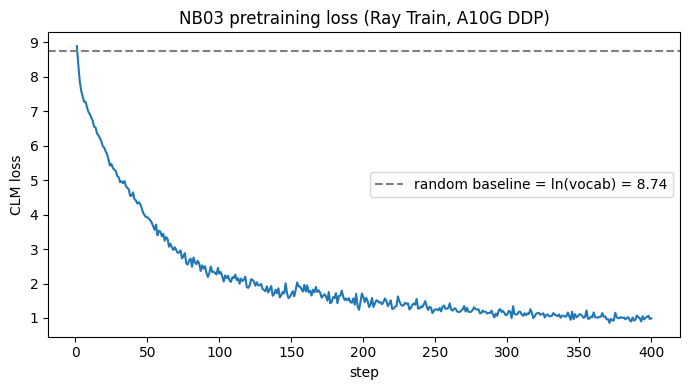

Saved /mnt/cluster_storage/tfm_ray/outputs/nb03_loss.png

HF checkpoint at /mnt/cluster_storage/tfm_ray/models/decoder-foundation-model:
  ['config.json', 'generation_config.json', 'model.safetensors', 'train_report.json']
  config.json: architectures=['LlamaForCausalLM'], hidden_size=512, vocab_size=6251

Checkpoint is HF-format -> AutoModelForCausalLM.from_pretrained() in NB04.


(autoscaler +2m25s) Tip: use `ray status` to view detailed cluster status. To disable these messages, set RAY_SCHEDULER_EVENTS=0.


In [4]:
%matplotlib inline
import matplotlib.pyplot as plt

report = json.loads((Path(out["final_dir"]) / "train_report.json").read_text())
losses = report["losses"]
print(f"Steps: {report['steps']} | final loss: {report['final_loss']:.3f} | "
      f"min loss: {report['min_loss']:.3f} | workers: {report['num_workers']}")

plt.figure(figsize=(7, 4))
plt.plot(range(1, len(losses) + 1), losses, color="#1f77b4")
import math
plt.axhline(math.log(C.MODEL_CONFIG["vocab_size"]), ls="--", color="gray",
            label=f"random baseline = ln(vocab) = {math.log(C.MODEL_CONFIG['vocab_size']):.2f}")
plt.xlabel("step"); plt.ylabel("CLM loss"); plt.legend(); plt.title("NB03 pretraining loss (Ray Train, A10G DDP)")
plt.tight_layout(); plt.savefig(C.OUTPUT_DIR / "nb03_loss.png", dpi=120)
plt.show()
print(f"Saved {C.OUTPUT_DIR / 'nb03_loss.png'}")

# Verify the HF checkpoint exists on shared storage (loadable in NB04).
ckpt = Path(out["final_dir"])
files = sorted(p.name for p in ckpt.iterdir())
print(f"\nHF checkpoint at {ckpt}:\n  {files}")
cfg_json = json.loads((ckpt / "config.json").read_text())
print(f"  config.json: architectures={cfg_json.get('architectures')}, "
      f"hidden_size={cfg_json.get('hidden_size')}, vocab_size={cfg_json.get('vocab_size')}")
assert (ckpt / "config.json").exists() and any(f.endswith(".safetensors") for f in files)
print("\nCheckpoint is HF-format -> AutoModelForCausalLM.from_pretrained() in NB04.")

## `Step 4`: Production note: NeMo AutoModel on Ray Train (hybrid)

To keep NeMo AutoModel's training loop (LR schedule, grad accumulation, FSDP2)
while gaining Ray's orchestration, wrap the NeMo recipe inside the same
`train_loop_per_worker` (per the migration plan):

```python
def train_loop_per_worker(cfg):
    from nemo_automodel.recipes.llm.train_ft import TrainFinetuneRecipeForNextTokenPrediction
    recipe = TrainFinetuneRecipeForNextTokenPrediction(cfg["nemo_cfg"])
    recipe.setup(); recipe.run_train_validation_loop()
# trainer = TorchTrainer(train_loop_per_worker, scaling_config=ScalingConfig(num_workers=8, use_gpu=True))
```

Ray then provides the process group, elastic/fault-tolerant workers and
checkpoint resume; NeMo provides the optimized recipe. The architecture and
tokenizer are identical to this notebook. (Requires the NeMo container/deps in
the worker `runtime_env` or image.)

## Summary

We pretrained the ~29M-param decoder with **Ray Train v2** across A10G GPUs:
a single `TorchTrainer.fit()` replaced `torchrun`+NeMo+FSDP2, Ray Data shards
replaced the text corpus, and the HF checkpoint landed on shared storage for
NB04. Scaling to more GPUs/nodes is just a larger `num_workers`.

**Output:** `models/decoder-foundation-model/` (HF `config.json` + `safetensors`).

Continue to **`04_inference_embedding_extraction_ray.ipynb`**.